In [4]:
import os
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tqdm

from IPython.display import display, HTML

from PIL import Image

import blockies
from blockies.plotvis import render_single_param, render_grid

In [5]:
# images_dir = Path('tutorial_images')
images_dir = Path('tutorial_tmp') # set to tmp so images aren't saved in tutorial folder

images_dir.mkdir(exist_ok=True)

resolution = (512, 512)

In [6]:
def get_rgb(color_val, cmap='coolwarm'):
    """Convert grayscale float to RGB tuple."""
    return plt.get_cmap(cmap)(color_val)

In [7]:
def sample_n(sampler, label, n):
    samples = []
    while len(samples) < n:
        sample = sampler()
        if sample.obj_name == label:
            samples.append(sample)

    return samples

In [8]:
def get_healthy(resolution=resolution):
  params = blockies.SceneParameters.default_healthy()
  params.sec_bones = '101'
  params.obj_color = .9
  params.bg_color = .1
  params.resolution = resolution

  params.obj_color_rgba = get_rgb(params.obj_color)
  params.bg_color_rgba = get_rgb(params.bg_color)

  return params

def get_ocd(resolution=resolution):
  params = blockies.SceneParameters.default_ocd()
  params.sec_bones = '111'
  params.obj_color = .1
  params.bg_color = .9
  params.resolution = resolution

  params.obj_color_rgba = get_rgb(params.obj_color)
  params.bg_color_rgba = get_rgb(params.bg_color)

  return params

In [9]:
sampler = blockies.BlockySampler()

# Introduction Examples

In [10]:
def_healthy_params = get_healthy()
def_ocd_params = get_ocd()

In [11]:
# render examples
def_healthy = blockies.blender.render_single(def_healthy_params)
def_ocd = blockies.blender.render_single(def_ocd_params)

In [12]:
img = Image.fromarray(def_healthy[0])
img.save(images_dir / 'intro_default_healthy.png')

img = Image.fromarray(def_ocd[0])
img.save(images_dir / 'intro_default_ocd.png')

In [13]:
# Display images side by side using HTML
display(HTML(
  f'<div style="display:flex;gap:10px">'
  f'<img src="{images_dir / "intro_default_healthy.png"}" width="256"/>'
  f'<img src="{images_dir / "intro_default_ocd.png"}" width="256"/>'
  f'</div>'
))

## Intro Collage

In [59]:
healthy_params = sample_n(sampler.sample, 'healthy', 9)
ocd_params = sample_n(sampler.sample, 'ocd', 9)

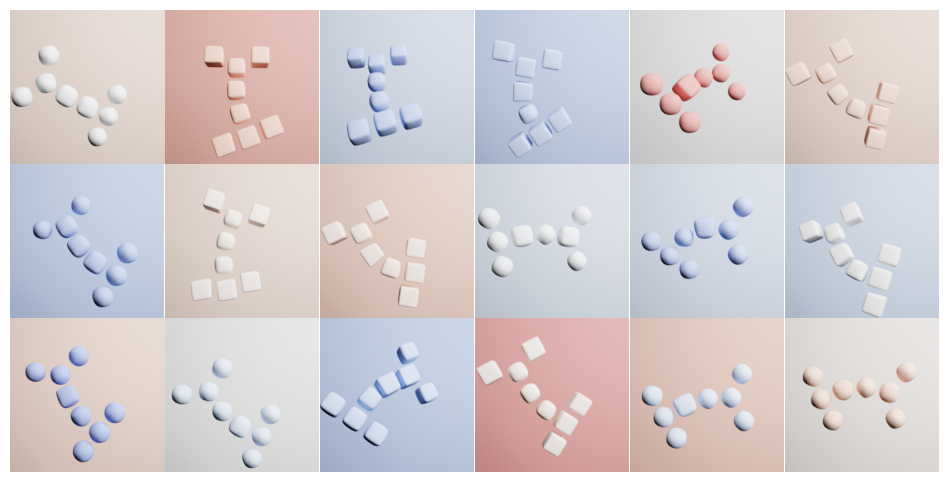

In [15]:
fig, ax = render_grid(healthy_params + ocd_params, label_class_axis=False)
fig.savefig(images_dir / 'intro_grid.png', dpi=300)

## UMAP26 Examples

In [60]:
healthy_imgs = [blockies.blender.render_single(p) for p in healthy_params]
ocd_imgs = [blockies.blender.render_single(p) for p in ocd_params]

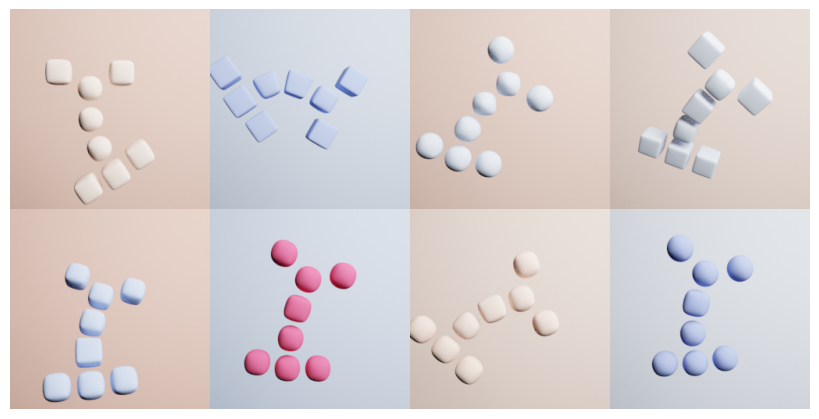

In [78]:
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for i, ax in enumerate(axes.flatten()):
    img = healthy_imgs[i][0]
    ax.imshow(img)
    ax.axis('off')

fig.subplots_adjust(
    left=0, right=1, bottom=0, top=1,
    wspace=0, hspace=0
)
fig.savefig(images_dir / 'intro_healthy_samples.png', dpi=300)


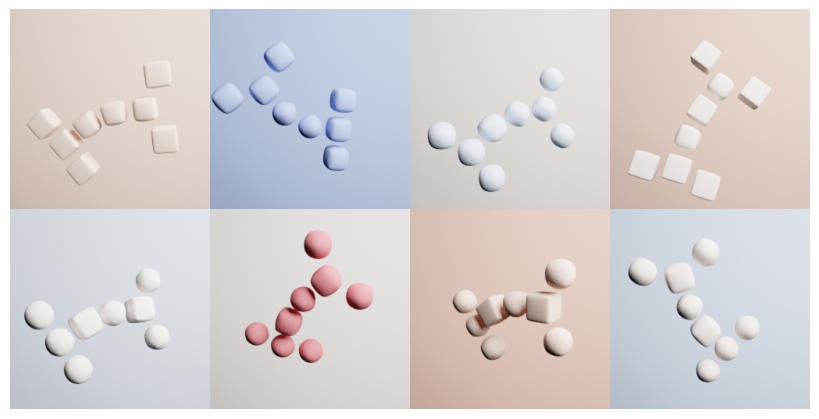

In [77]:
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for i, ax in enumerate(axes.flatten()):
    img = ocd_imgs[i][0]
    ax.imshow(img)
    ax.axis('off')

fig.subplots_adjust(
    left=0, right=1, bottom=0, top=1,
    wspace=0, hspace=0
)
fig.savefig(images_dir / 'intro_ocd_samples.png', dpi=300)


# Anatomy

In [13]:
def gen_sphere_diff_images(val_range, n_samples, filename_prefix):
    params = [get_healthy() for _ in range(n_samples)]
    vals = np.linspace(*val_range, n_samples)
    imgs = []
    paths = []
    for p, val in zip(params, vals):
        p.main_spherical = .9
        p.sec_spherical = p.main_spherical - val

        img = blockies.blender.render_single(p)[0]
        img = Image.fromarray(img)
        img.save(images_dir / f'{filename_prefix}_sphere_diff_neg_{val:.2f}.png')
        imgs.append(img)
        paths.append(images_dir / f'{filename_prefix}_sphere_diff_neg_{val:.2f}.png')

    for p, val in zip(params, vals):
        p.main_spherical = .1
        p.sec_spherical = p.main_spherical + val

        img = blockies.blender.render_single(p)[0]
        img = Image.fromarray(img)
        img.save(images_dir / f'{filename_prefix}_sphere_diff_pos_{val:.2f}.png')
        imgs.append(img)
        paths.append(images_dir / f'{filename_prefix}_sphere_diff_pos_{val:.2f}.png')

    return imgs, paths

In [14]:
def generate_images(val_range, n_samples, param_name, filename_prefix):
    params = [get_healthy() for _ in range(n_samples)]
    vals = np.linspace(*val_range, n_samples)
    imgs = []
    paths = []
    for p, val in zip(params, vals):
      setattr(p, param_name, val)

      # set rgb colors before rendering
      p.obj_color_rgba = get_rgb(p.obj_color)
      p.bg_color_rgba = get_rgb(p.bg_color)

      img = blockies.blender.render_single(p)[0]
      img = Image.fromarray(img)
      img.save(images_dir / f'{filename_prefix}_{param_name}_{val:.2f}.png')
      imgs.append(img)
      paths.append(images_dir / f'{filename_prefix}_{param_name}_{val:.2f}.png')
    return imgs, paths

def display_images(img_paths):
    __counter__ = random.randint(0,2e9) # hack to avoid caching in notebook
    img_str = ''.join(
      f'<img src="{path}?{__counter__}" width="128"/>' for path in img_paths
    )
    display(HTML(
      f'<div style="display:flex;gap:10px">'
      f'{img_str}'
      f'</div>'
    ))

### head (arm) position

In [15]:
param_name = 'arm_position'
val_range = (0.05, 0.45)
n_samples = 3
imgs, paths = generate_images(
    val_range, n_samples, param_name, 'anatomy_hly'
)

display_images(paths)

In [16]:
param_name = 'arm_position'
val_range = (0.55, 0.95)
n_samples = 3
imgs, paths = generate_images(
    val_range, n_samples, param_name, 'anatomy_ocd'
)

display_images(paths)

### bone shape

In [17]:
param_name = 'main_spherical'
val_range = (0.1, 0.9)
n_samples = 6
imgs, paths = generate_images(
    val_range, n_samples, param_name, 'anatomy_hly'
)

display_images(paths)

In [18]:
param_name = 'main_spherical'
val_range = (1.11, 1.22)
n_samples = 3
imgs, paths = generate_images(
    val_range, n_samples, param_name, 'anatomy_ocd'
)

display_images(paths)

### sphere diff

In [19]:
param_name = 'sphere_diff'
val_range = (0.1, 0.45)
n_samples = 3
imgs, paths = gen_sphere_diff_images(
    val_range, n_samples, 'anatomy_hly'
)
display_images(paths)

In [20]:
param_name = 'sphere_diff'
val_range = (0.55, 0.75)
n_samples = 3
imgs, paths = gen_sphere_diff_images(
    val_range, n_samples, 'anatomy_ocd'
)
display_images(paths)

### bending

In [21]:
param_name = 'bending'
val_range = (0.05, 0.175)
n_samples = 3
imgs, paths = generate_images(
    val_range, n_samples, param_name, 'anatomy_hly'
)
display_images(paths)

In [22]:
param_name = 'bending'
val_range = (0.225, 0.35)
n_samples = 3
imgs, paths = generate_images(
    val_range, n_samples, param_name, 'anatomy_ocd'
)
display_images(paths)

### colors

In [23]:
param_name = 'obj_color'
val_range = (0.05, 0.95)
n_samples = 5
imgs, paths = generate_images(
    val_range, n_samples, param_name, 'anatomy_hly'
)
display_images(paths)

In [24]:
param_name = 'bg_color'
val_range = (0.05, 0.95)
n_samples = 5
imgs, paths = generate_images(
    val_range, n_samples, param_name, 'anatomy_hly'
)
display_images(paths)

### Final X-Rays

In [25]:
healthy_imgs = [blockies.blender.render_single(p)[0] for p in healthy_params]
healthy_paths = [images_dir / f'anatomy_hly_final_{i}.png' for i in range(len(healthy_imgs))]

for img, path in zip(healthy_imgs, healthy_paths):
    img = Image.fromarray(img)
    img.save(path)

display_images(healthy_paths)

In [26]:
ocd_imgs = [blockies.blender.render_single(p)[0] for p in ocd_params]
ocd_paths = [images_dir / f'anatomy_ocd_final_{i}.png' for i in range(len(ocd_imgs))]

for img, path in zip(ocd_imgs, ocd_paths):
    img = Image.fromarray(img)
    img.save(path)

display_images(healthy_paths)

# practice

In [27]:
def generate_practice_data(params, folder):

    print(f"Rendering {len(params)} images...")
    for _ in tqdm.tqdm(blockies.render(
        params,
        n_processes=1,
        output_dir=folder,
        blender_dir=None,
        download_blender=False,
        print_output=False,
        print_cmd=False,
    ), total=len(params)):
        pass

In [28]:
def load_dataframe(data_dir, dataset):
  data_dir = data_dir / dataset
  df = pd.read_json(data_dir / 'parameters.jsonl', lines=True)
  df['filename'] = df['id'] + '.png'
  df['ill'] = (df['obj_name'] == 'ocd').astype(int)
  df['sphere_diff'] = (df.main_spherical - df.sec_spherical).abs()

  return df

In [29]:
char_map = {
    'high_sphere_diff': 'Strong Bone Shape Variation',
    'high_bend': 'Strong Spine Bend',
    'mutation_mainbones': 'Mutated Main Bones',
    'stretchy': 'Tucked Head'
}

def parse_chars(ill_chars):
    if len(ill_chars) == 0:
        return 'No Symptoms'
    elif len(ill_chars) == 1:
        return char_map[ill_chars[0]]
    else:
      char_str = ', '.join([char_map[c] for c in ill_chars[:-1]])
      char_str += f' & {char_map[ill_chars[-1]]}'
      return char_str

In [30]:
regenerate = False 

practice_dir = images_dir / 'practice'
(practice_dir / 'hly').mkdir(exist_ok=True, parents=True)
(practice_dir / 'ocd').mkdir(exist_ok=True, parents=True)

In [31]:
if regenerate:
  healthy_params = sample_n(sampler.sample, 'healthy', 10)
  ocd_params = sample_n(sampler.sample, 'ocd', 10)

  generate_practice_data(healthy_params, practice_dir / 'hly')
  generate_practice_data(ocd_params, practice_dir / 'ocd')

In [32]:
healthy_df = load_dataframe(practice_dir, 'hly')
ocd_df = load_dataframe(practice_dir, 'ocd')

In [33]:
# Display images side by side using HTML
hly_paths = [practice_dir / 'hly' / fname for fname in healthy_df['filename']]
ocd_paths = [practice_dir / 'ocd' / fname for fname in ocd_df['filename']]

In [34]:
display_images(hly_paths[:5])
display_images(hly_paths[5:])

In [35]:
for i, row in healthy_df.iterrows():
    print(row.id, parse_chars(row.ill_chars))

949ff767-6cf1-44a7-a67a-f33caef89d43 Tucked Head
06cefdae-5c35-4ab4-a741-c4074d18ff33 Strong Spine Bend
e837ab5a-2182-420b-af36-b0178c6653dc Strong Spine Bend
e1db17d2-f1ca-424a-8d97-1aa577d7c0c1 Tucked Head
325ff570-897b-4035-97b6-3cc0170cebab Strong Bone Shape Variation
d6626b2a-bd24-44fe-b68f-453d0e1cf2cd Strong Bone Shape Variation
387f4d10-deca-4919-8b1f-96f8bb9b2290 Mutated Main Bones
aa3ac0cb-f09e-44dc-84a5-33d0d744c7b0 Mutated Main Bones
246aef7d-a2ba-4bc6-b9d3-3efc54288475 No Symptoms
c275a7ff-31eb-468c-a3ae-f4db0f1ba04d Mutated Main Bones


In [36]:
display_images(ocd_paths[:5])
display_images(ocd_paths[5:])

In [55]:
def latex_parsechars(ill_chars):
    if len(ill_chars) == 0:
        return '{No Symptoms}'
    else:
      char_str = ','.join([char_map[c] for c in ill_chars])
      return '{' + char_str + '}'

for i, row in ocd_df.iterrows():
    # print(row.id, parse_chars(row.ill_chars))
    print(f'{row.id}.png/{latex_parsechars(row.ill_chars)},')

ad0440a1-39f9-4a4c-a2b1-ac817a2900f6.png/{Strong Bone Shape Variation,Mutated Main Bones},
186aa482-1177-4a6c-a7fa-5b500899cd2c.png/{Tucked Head,Strong Bone Shape Variation},
8f517279-cc63-421c-bdb0-1ee1f1e4b0d0.png/{Strong Bone Shape Variation,Strong Spine Bend},
5cfb3742-e247-44cd-8824-0eccd4b5397b.png/{Strong Spine Bend,Mutated Main Bones,Strong Bone Shape Variation},
6094b48d-37c6-471e-8c5c-91fd472f1c06.png/{Strong Bone Shape Variation,Mutated Main Bones},
f8f65d71-07d7-49fa-bb20-344427562275.png/{Tucked Head,Strong Bone Shape Variation},
6357fe9e-e45f-47e3-9f85-f0fd43de9b2d.png/{Mutated Main Bones,Tucked Head},
870a5d9f-f66f-4fef-b452-5c5f179ed737.png/{Strong Spine Bend,Tucked Head},
c4a68898-1388-4743-984f-2d4f7d914427.png/{Tucked Head,Strong Bone Shape Variation},
b540aac0-409a-4f79-8048-a6dfb3612451.png/{Mutated Main Bones,Tucked Head},


In [57]:
for i, row in ocd_df.sample(5).iterrows():
    # print(row.id, parse_chars(row.ill_chars))
    print(f'ocd/{row.id}.png,')

ocd/870a5d9f-f66f-4fef-b452-5c5f179ed737.png,
ocd/6094b48d-37c6-471e-8c5c-91fd472f1c06.png,
ocd/b540aac0-409a-4f79-8048-a6dfb3612451.png,
ocd/f8f65d71-07d7-49fa-bb20-344427562275.png,
ocd/ad0440a1-39f9-4a4c-a2b1-ac817a2900f6.png,


# compress folder

In [38]:
import shutil

shutil.make_archive('tutorial_images', 'zip', root_dir=images_dir)

'/home/djohnson/projects/blockies-haic/notebooks/tutorial_images.zip'